In [1]:
"""
Standalone v12 study pipeline for notebook use.

This is the selected v12 variant expressed as a single script with no
dependency on `common.py`.
"""

from functools import cache

import numpy as np
import pandas as pd

import qstudy as qs
from qstudy import Study
from qstudy.constants import SP500

START_DATE = "2015-01-01"
END_DATE = "2023-12-31"

In [8]:
@cache
def load_universe():
    return qs.download(SP500, START_DATE, END_DATE)


@cache
def load_benchmark():
    return qs.download("SPY", START_DATE, END_DATE)


def _rolling_momentum_frame(returns: pd.DataFrame, lookback: int, skip: int) -> pd.DataFrame:
    recent = returns.rolling(skip).mean() if skip > 0 else 0.0
    signal = returns.rolling(lookback).mean() - recent
    return signal.replace([np.inf, -np.inf], np.nan)


def benchmark_relative_momentum_signal(**cache):
    benchmark = cache["benchmark"].fillna(0.0)
    signal = _rolling_momentum_frame(cache["_active_returns"], lookback=252, skip=21)
    benchmark_signal = _rolling_momentum_frame(
        benchmark.to_frame("SPY"),
        lookback=252,
        skip=21,
    )["SPY"]
    relative = signal.sub(benchmark_signal, axis=0)
    return relative.shift(1)


def volume_confirmation_filter(signal, **cache):
    volume = cache["volume"]
    volume_z = (volume - volume.rolling(30).mean()) / volume.rolling(30).std()
    trailing = cache["_active_returns"].rolling(63).mean()
    mask = volume_z.gt(volume_z.quantile(0.7, axis=1), axis=0) & trailing.gt(0.0)
    return signal.where(mask)


def relative_volume_strength_filter(signal, **cache):
    volume = cache["volume"]
    ratio = volume.div(volume.rolling(63).mean())
    mask = ratio.gt(ratio.quantile(0.8, axis=1), axis=0)
    return signal.where(mask)


def positive_momentum_filter(signal, **cache):
    return signal.where(signal > 0.0)


def min_universe_breadth_filter(signal, **cache):
    breadth = signal.notna().sum(axis=1)
    active_dates = breadth >= 15
    return signal.where(active_dates, other=np.nan, axis=0)


def benchmark_trend_scale(positions, **cache):
    benchmark = cache["benchmark"].fillna(0.0)
    benchmark_price = (1.0 + benchmark).cumprod()
    fast_ma = benchmark_price.rolling(80).mean()
    slow_ma = benchmark_price.rolling(220).mean()
    scale = pd.Series(np.where(fast_ma >= slow_ma, 1.0, 0.6), index=benchmark_price.index)
    return positions.mul(scale.shift(1).fillna(1.0), axis=0)


study = (
    Study(
        universe=load_universe(),
        benchmark=load_benchmark(),
        name="sp500_xsect_momentum_v12_single",
    )
    .base_signal(benchmark_relative_momentum_signal)
    .add_filter(volume_confirmation_filter)
    .add_filter(relative_volume_strength_filter)
    .add_filter(positive_momentum_filter)
    .add_filter(min_universe_breadth_filter)
    .add_tradeable_constraint(qs.min_adv(30_000_000.0))
    .add_tradeable_constraint(qs.liquidity(top_n=90, window=63))
    .build_long_only(n=15)
    .rebalance(every=30)
    .scale_risk(benchmark_trend_scale)
    .scale_risk(vol_target=0.16)
    .weight_equal_sharpe(window=126)
    .run()
)


$GEV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
$SOLV: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")

2 Failed downloads:
['GEV', 'SOLV']: possibly delisted; no price data found  (1d 2015-01-01 -> 2023-12-31) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1703998800")
sp500_xsect_momentum_v12_single: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 31.09it/s, stage=metrics]


sharpe                              0.948864
ann_return                          0.200272
ann_vol                             0.217281
max_drawdown                       -0.291355
max_drawdown_duration                    297
max_drawdown_start       2021-11-26 00:00:00
max_drawdown_end         2023-02-01 00:00:00
avg_daily_turnover                  0.846355
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                       0.66168
information_ratio                    0.46903


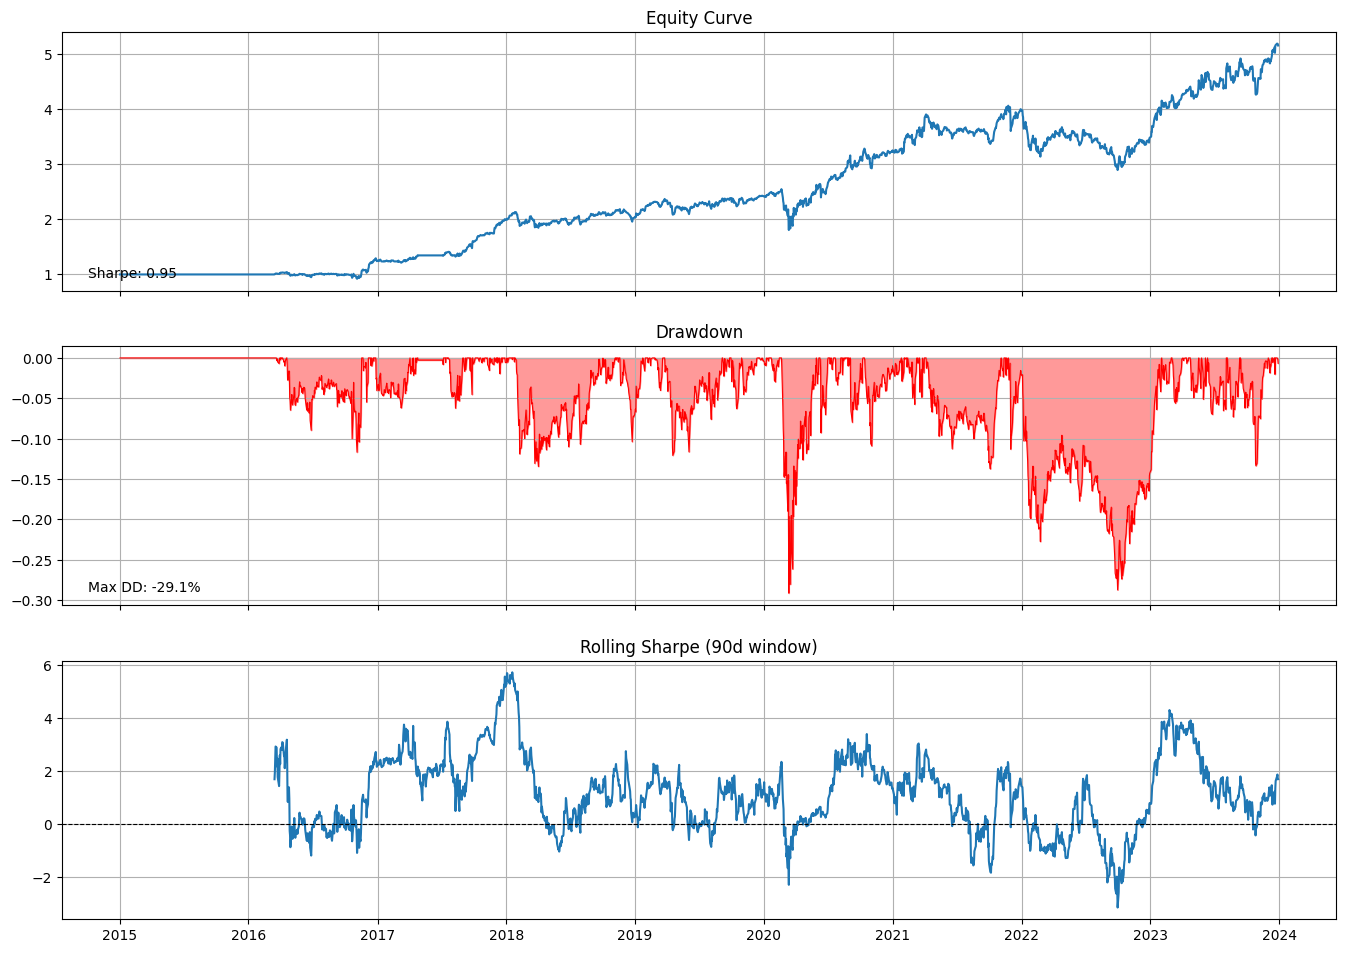

Study(name='sp500_xsect_momentum_v12_single', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler', 'position_scaler'], weighting=True, ran=True)

In [9]:
study.report()

sharpe                              0.901189
ann_return                          0.203786
ann_vol                             0.236928
max_drawdown                         -0.3096
max_drawdown_duration                    365
max_drawdown_start       2018-01-29 00:00:00
max_drawdown_end         2019-07-11 00:00:00
avg_daily_turnover                  0.846355
benchmark_ann_return                0.117774
benchmark_sharpe                    0.706393
benchmark_corr                      0.686713
information_ratio                   0.494944


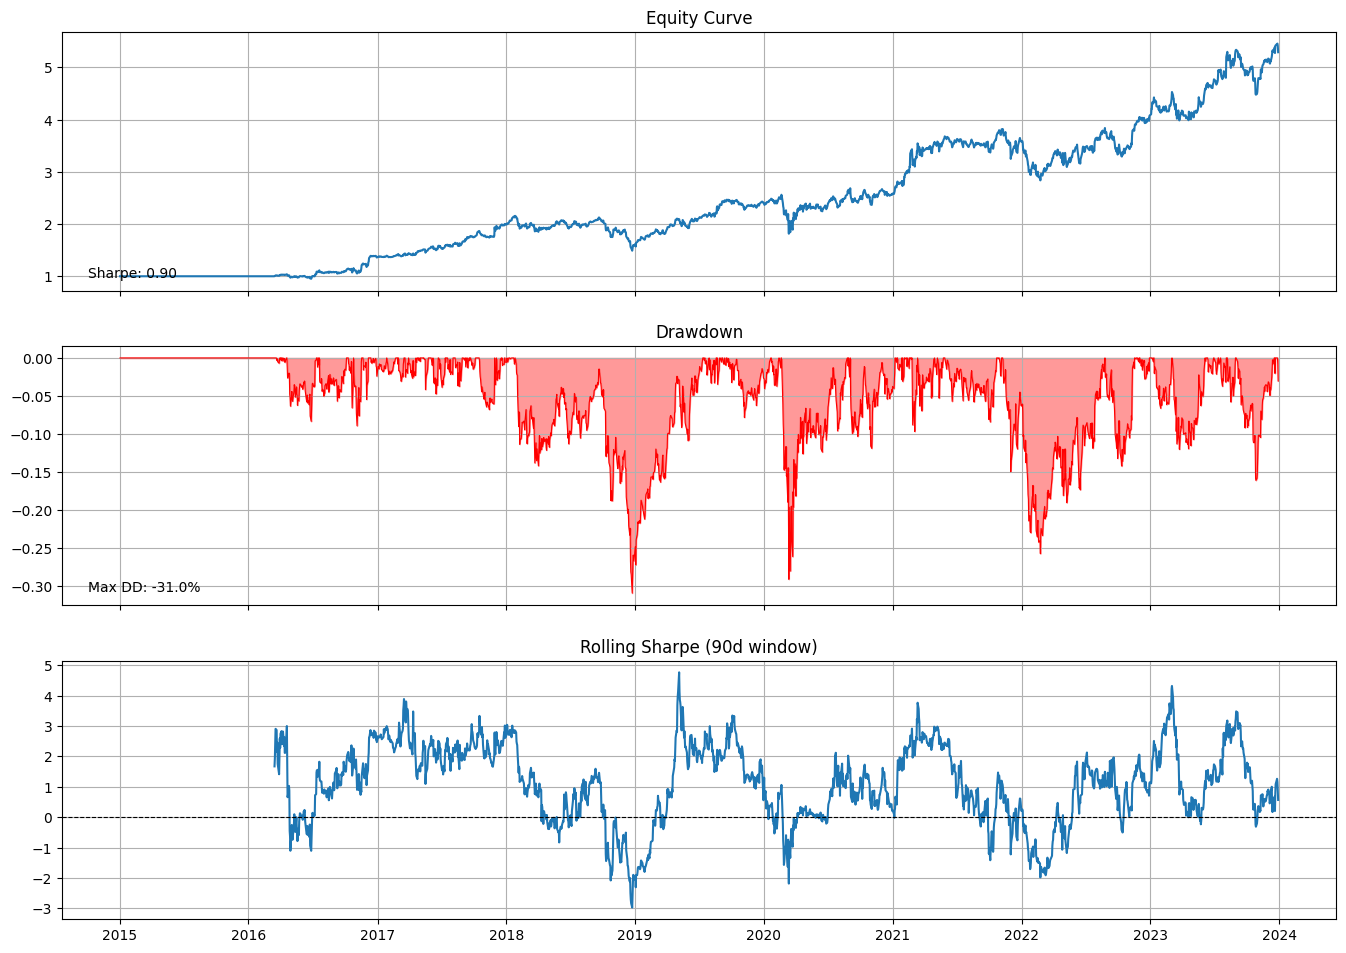

Study(name='sp500_xsect_momentum_v12_single', steps=['base_signal', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'signal_filter', 'position_builder', 'position_scaler', 'position_scaler', 'position_scaler'], weighting=True, ran=True)

In [5]:
study.report()